In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./data/raw_data/merged_data.csv')
df.head(5)

,date,occupation,channel,place,gender,ageRange,question_raw,answer_raw
0,20230116,ARD,MOCK,ONLINE,FEMALE,-34,면접자께서는 지금부터 삼 년 뒤까지 삼 년 내 주요 성장 계획이나 목표가 있으십니까...,네 저는 디자이너로서 삼 년 안에 저만의 브랜드를 만드는 게 목표입니다. 어 아직까...
1,20230116,ARD,MOCK,ONLINE,FEMALE,-34,업무를 하다가 만일 상사가 지원자님에게 어려운 지시를 준다면 어떻게 극복하시겠어요,네 디자인을 하다가 제가 이제 메인 디자이너 상사께 받은 여러 가지 지시 사항이 있...
2,20230116,ARD,MOCK,ONLINE,FEMALE,-34,그 이전 직장에서 그 퇴사를 하셨는데요 뭐 퇴사하신 것을 혹시라도 후회하신 적은 없...,네 저는 전에 직장에서 일할 수 있었다는 걸 굉장히 감사하게 생각을 하고요. 퇴사한...
3,20230116,ARD,MOCK,ONLINE,FEMALE,-34,주로 영감은 어디에서 찾으시나요,네 디자인 일을 할 때는 아무래도 영감 그리고 아이디어를 얻는 일이 참 중요합니다....
4,20230116,ARD,MOCK,ONLINE,FEMALE,-34,일을 하다 보면 상사와 트러블이 생길 수가 있는데요 어떻게 하면 좋을까요 또 상사가...,네 일단 업무를 하다보면 어 상사와 트러블이 발생할 수도 있을 것 같습니다. 그리고...


In [3]:
df_ict = df[df['occupation'] == 'ICT'] 
df_rnd = df[df['occupation'] == 'RND']

In [4]:
df = pd.concat([df_ict, df_rnd], ignore_index=True)
df = df[['question_raw','answer_raw']]
df.to_csv('./data/data_preprocessing/sorted_data.csv', index=False, encoding='utf-8-sig')

In [5]:
df = pd.read_csv('./data/data_preprocessing/sorted_data.csv')
df.head(5)

,question_raw,answer_raw
0,지원자님 일을 하다 보면 영어로 서류를 작성해야 할 일이 생길 수 있습니다 지원자님...,네 가능합니다. 영어로 서류를 작성해야 할 시에 할 시를 대비하기 위해서 어 많은 ...
1,커뮤니케이션을 잘 할 수 있는 본인만의 스킬이 있나요 있다면 저희에게 한 번 직접 ...,커뮤니케이션을 잘 할 수 있는 저만의 스킬은 소소하게 스물 토크를 통해서 하는 것인...
2,어 지원장님은 의견을 주장해야 될 때 강하게 주장을 하시나요 아니면 약하게 하시나요...,의견을 주장할 때 원래는 강하게 하는 편이었는데 요즘은 강하게 하기 보다는 적당하게...
3,지금까지 살아오시면서 가장 힘들었던 경험에는 어떤 것이 있는지요 그 경험도 말씀해 ...,지금까지 살아오면서 가장 힘들었던 경험은 대학 입시에서 과를 결정하는 데 부모님과 ...
4,면접자분이 역사 속에서 가장 존경하는 일 인물을 말씀해 주시고 그리고 왜 그 인물을...,역사 속에서 가장 존경하는 인물은 성경에 나오는 인물인 모세인데요. 모세는 이스라엘...


In [6]:
# 한글 아닌 데이터 제거
df['question_raw'] = df['question_raw'].replace(r'[^0-9가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', regex=True)
df['answer_raw'] = df['answer_raw'].replace(r'[^0-9가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', regex=True)

In [7]:
from tqdm import tqdm
from konlpy.tag import Okt
# def load_ko_stopwords(filepath):
#     with open(filepath, 'r', encoding='UTF-8') as f:
#         return [line.strip() for line in f]

okt = Okt()

def load_ko_stopwords(filepath):
    with open(filepath, 'r', encoding='UTF-8') as f:
        return [line.strip() for line in f]
    
def get_core_sentence(text):
    sentences = [s.strip() for s in text.split('.') if s.strip()]
    
    if len(sentences) >= 1:
        return sentences[0] + '.'
    return text

def preprocess(sentences, ko_stopwords, answer=False):
    result = []
    for sentence in tqdm(sentences):
        if answer:
            sentence = get_core_sentence(sentence)
        tokens = okt.morphs(sentence)

        if answer:
            tokens = ['<sos>'] + tokens + ['<eos>']
        else:
            tokens = tokens + ['<eos>']

        tokens = [token for token in tokens if token not in ko_stopwords]
        result.append(tokens)
    return result

ko_stopwords = load_ko_stopwords('./ko_stopwords.txt')
question = preprocess(df['question_raw'], ko_stopwords)
answer = preprocess(df['answer_raw'], ko_stopwords, answer=True)

100%|██████████| 11926/11926 [02:05<00:00, 95.38it/s] 


In [8]:
import torch
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

BATCH_SIZE = 64                # 배치 크기
MAX_VOCAB_SIZE = 10000         # 단어사전 크기
EMBEDDING_DIM = 128            # 임베딩 차원
LATENT_DIM = 256               # 뉴런 수

In [9]:
# 토크나이저, 정수 시퀀스 변환
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<UNK>')
tokenizer.fit_on_texts(question + answer)

question_seq = tokenizer.texts_to_sequences(question)
answer_seq = tokenizer.texts_to_sequences(answer)

In [10]:
# 최대 문장 길이 확인
# num_words = len(tokenizer.word_index) + 1
num_words = MAX_VOCAB_SIZE
q_max_len = max(len(s) for s in question_seq)
a_max_len = max(len(s) for s in answer_seq)

print(f'{num_words = }')
print(f'{q_max_len = }')
print(f'{a_max_len = }')

num_words = 10000
q_max_len = 57
a_max_len = 420


In [11]:
import numpy as np
lengths = [len(s) for s in answer_seq]
print(np.percentile(lengths, [25, 50, 75, 90, 95]))

[142. 176. 217. 251. 269.]


In [12]:
q_len = 40
a_len = 200

# 패딩: 질문이 훨씬 짧으므로 pre로 설정
question_input = pad_sequences(question_seq, maxlen=q_len, padding='pre')
answer_input = pad_sequences(answer_seq, maxlen=a_len, padding='post')

print(question_input.shape)
print(answer_input.shape)

print(question_input[1000])
print([tokenizer.index_word[s] for s in question_input[1000] if s != 0])
print(answer_input[1000])
print([tokenizer.index_word[s] for s in answer_input[1000] if s != 0])

(11926, 40)
(11926, 200)
[   0    0    0    0    0    0    0    0    0  418    6 5606   18  219
  306   37  471    8   83   61    9 1967  471   39  503  610   23   44
   73    2    1 3681    6  115   54   22  147  192  159   14]
['개발자', '가', '갖추어야', '할', '중요한', '역량', '과', '태도', '는', '무엇', '이라고', '생각', '하시고', '태도', '로', '인해서', '긍정', '적', '인', '경험', '을', '<UNK>', '케이스', '가', '있다면', '말씀', '해', '주', '시기', '바랍니다', '<eos>']
[  32  418   57  219    7   17    1   61    9   28 2242   37 1756  474
    3 3911  124    2   36   18   13  113    9   65  898  991   83  162
   38  219    7   17    1   61    9   28  124  229    7   17 2566   30
 1646    5 2301   16    7   42  184   26    4 2242   37 1756  474   24
 1399  210    7    2  274    7   30  210    7    2  467 5804    7   17
   60  656   37 1670    5 5042 2738    7    3  124   42  184   26    4
  124    2   84 1004    3   83  137 7840 1004    2   69   19   52 1004
    2 1367   69   19    3    7    2  923   16    7    3  124   42  184
   26    4

In [13]:
class InterviewDataset(Dataset):
    def __init__(self, question_input, answer_input):
        self.question_input = torch.tensor(question_input, dtype=torch.long)
        self.answer_input = torch.tensor(answer_input, dtype=torch.long)
        
    def __len__(self):
        return len(self.question_input)
    
    def __getitem__(self, idx):
        return self.question_input[idx], self.answer_input[idx]

In [14]:
X_train, X_val, y_train, y_val = train_test_split(question_input, answer_input, test_size=0.2, random_state=42)

train_dataset = InterviewDataset(X_train, y_train)
val_dataset = InterviewDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, BATCH_SIZE)

print('학습 데이터 배치 개수:', len(train_loader))

학습 데이터 배치 개수: 150


In [15]:
# 인코더
class Encoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.gru = nn.GRU(embedding_dim, latent_dim, batch_first=True)

  def forward(self, input_seq):
    input_seq = self.embedding(input_seq)
    outputs, hidden = self.gru(input_seq)
    return hidden

In [16]:
# 디코더
class Decoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.gru = nn.GRU(embedding_dim, latent_dim, batch_first=True)
    self.fc = nn.Linear(latent_dim, vocab_size)

  def forward(self, input_seq, hidden):
    input_seq = self.embedding(input_seq)
    output, hidden = self.gru(input_seq, hidden)
    predict = self.fc(output)
    return predict, hidden

In [17]:
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# seq2seq
class Seq2Seq(nn.Module):
  def __init__(self, encoder, decoder, device):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.device = device

  def forward(self, question, answer, teacher_forcing=0.8):
    batch_size = answer.shape[0]
    target_len = answer.shape[1]
    target_vocab_size = self.decoder.fc.out_features

    outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(self.device)
    hidden = self.encoder(question)

    input_first = answer[:, 0].unsqueeze(1)
    
    for target in range(1, target_len):
      output, hidden = self.decoder(input_first, hidden)
      outputs[:, target, :] = output.squeeze(1)

      teacher_force = random.random() < teacher_forcing
      top = output.argmax(2)

      input_first = answer[:, target].unsqueeze(1) if teacher_force else top

    return outputs

In [18]:
encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)

model = Seq2Seq(encoder, decoder, device).to(device)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10000, 128)
    (gru): GRU(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 128)
    (gru): GRU(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=10000, bias=True)
  )
)

In [19]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
epochs = 10

train_losses, train_accs, val_losses, val_accs = [], [], [], [] 

In [55]:


for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_tokens = 0, 0, 0

    p_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for q_batch, a_batch in p_bar:
        q_batch, a_batch = q_batch.to(device), a_batch.to(device)
        
        optimizer.zero_grad()
        output = model(q_batch, a_batch)
        
        loss = criterion(output.view(-1, num_words), a_batch.view(-1))
        loss.backward()
        optimizer.step()

        current_loss = loss.item()
        train_loss += current_loss
        p_bar.set_postfix(loss=f"{current_loss:.4f}")

        preds = output.argmax(dim=-1)
        mask = a_batch != 0
        train_correct += ((preds == a_batch) & mask).sum().item()
        train_tokens += mask.sum().item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_tokens

    model.eval()
    val_loss, val_correct, val_tokens = 0, 0, 0
    with torch.no_grad():
        for q_batch, a_batch in val_loader:
            q_batch, a_batch = q_batch.to(device), a_batch.to(device)
            output = model(q_batch, a_batch)
            
            loss = criterion(output.view(-1, num_words), a_batch.view(-1))
            val_loss += loss.item()

            preds = output.argmax(dim=-1)
            mask = a_batch != 0
            val_correct += ((preds == a_batch) & mask).sum().item()
            val_tokens += mask.sum().item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_correct / val_tokens
    
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    print(f'[{epoch+1}/{epochs}] T_Loss: {avg_train_loss:.4f} | T_Acc: {avg_train_acc:.4f} | V_Loss: {avg_val_loss:.4f} | V_Acc: {avg_val_acc:.4f}')

Epoch 1: 100%|██████████| 150/150 [23:36<00:00,  9.44s/it, loss=5.7090]


[1/10] T_Loss: 6.4995 | T_Acc: 0.0837 | V_Loss: 5.9526 | V_Acc: 0.1303


Epoch 2: 100%|██████████| 150/150 [22:28<00:00,  8.99s/it, loss=5.2955]


[2/10] T_Loss: 5.7179 | T_Acc: 0.1531 | V_Loss: 5.5239 | V_Acc: 0.1712


Epoch 3: 100%|██████████| 150/150 [22:01<00:00,  8.81s/it, loss=5.0850]


...

[8/10] T_Loss: 4.7709 | T_Acc: 0.2235 | V_Loss: 4.8474 | V_Acc: 0.2230


Epoch 9: 100%|██████████| 150/150 [20:40<00:00,  8.27s/it, loss=4.4213]


[9/10] T_Loss: 4.6867 | T_Acc: 0.2285 | V_Loss: 4.7974 | V_Acc: 0.2272


Epoch 10: 100%|██████████| 150/150 [20:37<00:00,  8.25s/it, loss=4.5511]


[10/10] T_Loss: 4.6225 | T_Acc: 0.2322 | V_Loss: 4.7597 | V_Acc: 0.2292


In [56]:
# 모델 저장
torch.save(model, 'interview_model.pth')

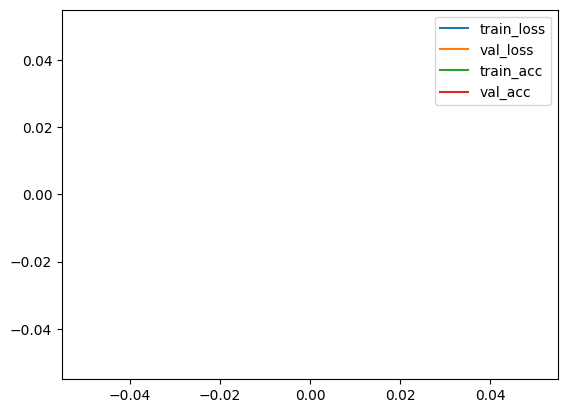

In [20]:
import matplotlib.pyplot as plt

pd.DataFrame({
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs,
}).plot()
plt.show()

In [21]:
model = torch.load('interview_model.pth', weights_only=False)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10000, 128)
    (gru): GRU(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 128)
    (gru): GRU(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=10000, bias=True)
  )
)

In [31]:
def predict(question_str, model, tokenizer, max_len=100, temperature=0.8):
    model.eval()
    with torch.no_grad():
        tokens = okt.morphs(question_str) 
        tokens = tokens + ['<eos>']
        
        seq = tokenizer.texts_to_sequences([tokens])
        input_tensor = torch.tensor(pad_sequences(seq, maxlen=40, padding='pre')).to(device)

        hidden = model.encoder(input_tensor)

        start_token = tokenizer.word_index.get('<sos>', 2) 
        input_step = torch.tensor([[start_token]]).to(device)

        result = []
        for _ in range(max_len):
            output, hidden = model.decoder(input_step, hidden)
            # top1 = output.argmax(2) 
            logits = output.squeeze(1) / temperature
            probs = torch.softmax(logits, dim=-1)
            top1 = torch.multinomial(probs, num_samples=1)
            
            idx = top1.item()
            if idx == tokenizer.word_index.get('<eos>', 3) or idx == 0:
                break
                
            word = tokenizer.index_word.get(idx, '<UNK>')
            result.append(word)
            
            input_step = top1

    return ' '.join(result)

test_question = "입사 후 계획이 있나요?"
ans = predict(test_question, model, tokenizer)

print(f"질문: {test_question}")
print(f"답변: {ans}")

질문: 입사 후 계획이 있나요?
답변: 저 는 기차 에 에서 프로그래밍 만 진행 을 할 때 좋은 방법 이라고 생각 하고 있습니다 그때 는 책 을 읽는 것 이나 <UNK> 를 을 보면 분 들 이 <UNK> 가 쌓였을 때 그걸 보면 <UNK> <UNK> <UNK> 해서 알려 해 볼 수 있었습니다 제 가 원하는 만큼 아이디어 를 대해 서 <UNK> 위해 서 노력 하고 있습니다 그렇기 때문 에 저 평소 에 다른 사람 들 의 아이디어 와 소통 을 한다면 실천 을 잘 <UNK> 잘 될 수 있기 때문 이 이 제 스토리 과 <UNK> 잘 합니다 있고 스트레스 가 해소 되고 <UNK> 생각 을
